In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
import os

# ─── 1. CHARGEMENT DES DONNÉES ────────────────────────────
X_train = np.load("../data/X_train.npy")
X_val   = np.load("../data/X_val.npy")
X_test  = np.load("../data/X_test.npy")
y_train = np.load("../data/y_train.npy")
y_val   = np.load("../data/y_val.npy")
y_test  = np.load("../data/y_test.npy")
class_names = list(np.load("../data/class_names.npy"))

print(f"Train : {X_train.shape} | Val : {X_val.shape} | Test : {X_test.shape}")
print(f"Classes ({len(class_names)}) : {class_names}")




C:\Users\fatima zehra\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\fatima zehra\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\fatima zehra\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_

Train : (18028, 28, 28, 1) | Val : (3851, 28, 28, 1) | Test : (3861, 28, 28, 1)
Classes (33) : [np.str_('ya'), np.str_('yab'), np.str_('yach'), np.str_('yad'), np.str_('yadd'), np.str_('yae'), np.str_('yaf'), np.str_('yag'), np.str_('yagh'), np.str_('yagw'), np.str_('yah'), np.str_('yahh'), np.str_('yaj'), np.str_('yak'), np.str_('yakw'), np.str_('yal'), np.str_('yam'), np.str_('yan'), np.str_('yaq'), np.str_('yar'), np.str_('yarr'), np.str_('yas'), np.str_('yass'), np.str_('yat'), np.str_('yatt'), np.str_('yaw'), np.str_('yax'), np.str_('yay'), np.str_('yaz'), np.str_('yazz'), np.str_('yey'), np.str_('yi'), np.str_('yu')]


C:\Users\fatima zehra\AppData\Roaming\Python\Python313\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [3]:
# ─── 2. ARCHITECTURE CNN ──────────────────────────────────
# Dataset manuscrit réel → le modèle doit vraiment apprendre les formes
# Accuracy attendue : 85–93%
tf.keras.backend.clear_session()

model = Sequential([
    # Bloc 1
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28,28,1)),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Bloc 2
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Bloc 3
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Classificateur
    Flatten(),
    Dense(128, activation='relu', kernel_regularizer=l2(1e-3)),
    Dropout(0.40),
    Dense(len(class_names), activation='softmax')  # 33 classes AMHCD
])

model.summary()



C:\Users\fatima zehra\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 33)             │         4,257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,497 (525.38 KB)

 Trainable params: 134,177 (524.13 KB)

 Non-trainable params: 320 (1.25 KB)

In [4]:
# ─── 3. COMPILATION ───────────────────────────────────────
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)




In [5]:
# ─── 4. CALLBACKS ─────────────────────────────────────────
os.makedirs("../results/models", exist_ok=True)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ModelCheckpoint("../results/models/best_model.h5", monitor='val_accuracy',
                    save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4,
                      verbose=1, min_lr=1e-6)
]



In [6]:

# ─── 5. AUGMENTATION + ENTRAÎNEMENT ───────────────────────
# Dataset manuscrit : variabilité naturelle présente
# → augmentation légère suffit, pas besoin de bruit artificiel
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    shear_range=0.05,
    fill_mode='nearest'
)


class AugmentedGenerator(tf.keras.utils.Sequence):
    def __init__(self, X, y, batch_size=64, augment=True):
        self.X, self.y  = X, y
        self.batch_size = batch_size
        self.augment    = augment
        self.datagen    = datagen
        self.datagen.fit(X)

    def __len__(self):
        return int(np.ceil(len(self.X) / self.batch_size))

    def __getitem__(self, idx):
        X_batch = self.X[idx*self.batch_size:(idx+1)*self.batch_size]
        y_batch = self.y[idx*self.batch_size:(idx+1)*self.batch_size]
        if self.augment:
            X_aug = np.array([self.datagen.random_transform(x) for x in X_batch])
            return X_aug, y_batch
        return X_batch, y_batch


train_gen = AugmentedGenerator(X_train, y_train, batch_size=64, augment=True)
val_gen   = AugmentedGenerator(X_val,   y_val,   batch_size=64, augment=False)

print("\n Entraînement en cours...")
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=callbacks,
    verbose=1
)





 Entraînement en cours...
Epoch 1/30


C:\Users\fatima zehra\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


281/282 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.1057 - loss: 3.6170
Epoch 1: val_accuracy improved from None to 0.09192, saving model to ../results/models/best_model.h5



Epoch 1: finished saving model to ../results/models/best_model.h5
282/282 ━━━━━━━━━━━━━━━━━━━━ 16s 44ms/step - accuracy: 0.2644 - loss: 2.8327 - val_accuracy: 0.0919 - val_loss: 5.8399 - learning_rate: 0.0010
Epoch 2/30
281/282 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.7067 - loss: 1.1315
Epoch 2: val_accuracy improved from 0.09192 to 0.15684, saving model to ../results/models/best_model.h5



Epoch 2: finished saving model to ../results/models/best_model.h5
282/282 ━━━━━━━━━━━━━━━━━━━━ 16s 58ms/step - accuracy: 0.7548 - loss: 0.9742 - val_accuracy: 0.1568 - val_loss: 5.9395 - learning_rate: 0.0010
Epoch 3/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.8416 - loss: 0.6916
Epoch 3: val_accuracy improved from 0.15684 to 0.74890, saving model to ../results/models/best_model.h5


...


Epoch 12: finished saving model to ../results/models/best_model.h5
282/282 ━━━━━━━━━━━━━━━━━━━━ 20s 70ms/step - accuracy: 0.9511 - loss: 0.2528 - val_accuracy: 0.9514 - val_loss: 0.2439 - learning_rate: 0.0010
Epoch 13/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.9533 - loss: 0.2397
Epoch 13: val_accuracy did not improve from 0.95144
282/282 ━━━━━━━━━━━━━━━━━━━━ 19s 67ms/step - accuracy: 0.9514 - loss: 0.2509 - val_accuracy: 0.8704 - val_loss: 0.5061 - learning_rate: 0.0010
Epoch 14/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9502 - loss: 0.2498
Epoch 14: val_accuracy improved from 0.95144 to 0.95560, saving model to ../results/models/best_model.h5



Epoch 14: finished saving model to ../results/models/best_model.h5
282/282 ━━━━━━━━━━━━━━━━━━━━ 18s 64ms/step - accuracy: 0.9508 - loss: 0.2444 - val_accuracy: 0.9556 - val_loss: 0.2121 - learning_rate: 0.0010
Epoch 15/30
281/282 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9588 - loss: 0.2221
Epoch 15: val_accuracy did not improve from 0.95560
282/282 ━━━━━━━━━━━━━━━━━━━━ 18s 64ms/step - accuracy: 0.9566 - loss: 0.2300 - val_accuracy: 0.7289 - val_loss: 1.1804 - learning_rate: 0.0010
Epoch 16/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.9581 - loss: 0.2240
Epoch 16: val_accuracy did not improve from 0.95560
282/282 ━━━━━━━━━━━━━━━━━━━━ 20s 72ms/step - accuracy: 0.9569 - loss: 0.2245 - val_accuracy: 0.2145 - val_loss: 20.3130 - learning_rate: 0.0010
Epoch 17/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9589 - loss: 0.2213
Epoch 17: val_accuracy did not improve from 0.95560
282/282 ━━━━━━━━━━━━━━━━━━━━ 18s 64ms/step - accuracy: 0.9587 - loss: 0.2220 - val


Epoch 19: finished saving model to ../results/models/best_model.h5
282/282 ━━━━━━━━━━━━━━━━━━━━ 29s 103ms/step - accuracy: 0.9642 - loss: 0.1933 - val_accuracy: 0.9572 - val_loss: 0.2036 - learning_rate: 5.0000e-04
Epoch 20/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.9705 - loss: 0.1743
Epoch 20: val_accuracy did not improve from 0.95715
282/282 ━━━━━━━━━━━━━━━━━━━━ 31s 111ms/step - accuracy: 0.9682 - loss: 0.1795 - val_accuracy: 0.9447 - val_loss: 0.2297 - learning_rate: 5.0000e-04
Epoch 21/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.9685 - loss: 0.1758
Epoch 21: val_accuracy did not improve from 0.95715
282/282 ━━━━━━━━━━━━━━━━━━━━ 39s 137ms/step - accuracy: 0.9683 - loss: 0.1744 - val_accuracy: 0.8567 - val_loss: 0.5217 - learning_rate: 5.0000e-04
Epoch 22/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.9703 - loss: 0.1627
Epoch 22: val_accuracy did not improve from 0.95715
282/282 ━━━━━━━━━━━━━━━━━━━━ 27s 97ms/step - accuracy: 0.9698 - lo


Epoch 23: finished saving model to ../results/models/best_model.h5
282/282 ━━━━━━━━━━━━━━━━━━━━ 25s 90ms/step - accuracy: 0.9727 - loss: 0.1564 - val_accuracy: 0.9914 - val_loss: 0.0967 - learning_rate: 5.0000e-04
Epoch 24/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9688 - loss: 0.1590
Epoch 24: val_accuracy did not improve from 0.99143
282/282 ━━━━━━━━━━━━━━━━━━━━ 21s 73ms/step - accuracy: 0.9691 - loss: 0.1618 - val_accuracy: 0.9561 - val_loss: 0.1937 - learning_rate: 5.0000e-04
Epoch 25/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9697 - loss: 0.1568
Epoch 25: val_accuracy did not improve from 0.99143
282/282 ━━━━━━━━━━━━━━━━━━━━ 18s 64ms/step - accuracy: 0.9699 - loss: 0.1561 - val_accuracy: 0.7341 - val_loss: 1.6972 - learning_rate: 5.0000e-04
Epoch 26/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9727 - loss: 0.1462
Epoch 26: val_accuracy did not improve from 0.99143
282/282 ━━━━━━━━━━━━━━━━━━━━ 21s 75ms/step - accuracy: 0.9723 - loss: 0


Epoch 30: finished saving model to ../results/models/best_model.h5
282/282 ━━━━━━━━━━━━━━━━━━━━ 18s 64ms/step - accuracy: 0.9773 - loss: 0.1256 - val_accuracy: 0.9932 - val_loss: 0.0696 - learning_rate: 2.5000e-04
Restoring model weights from the end of the best epoch: 30.


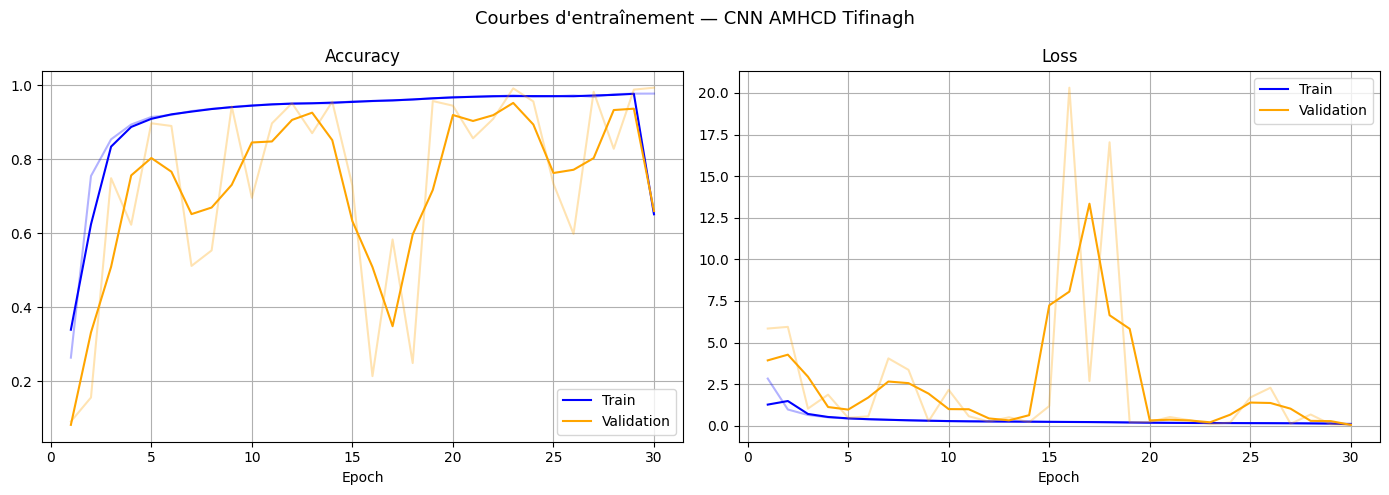

In [7]:
# ─── COURBES───────
import numpy as np
import matplotlib.pyplot as plt

def lisser(valeurs, fenetre=3):
    """Moyenne glissante pour lisser une courbe bruitée."""
    return np.convolve(valeurs, np.ones(fenetre)/fenetre, mode='same')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(history.history['accuracy']) + 1)

# Accuracy
axes[0].plot(epochs, history.history['accuracy'], alpha=0.3, color='blue')
axes[0].plot(epochs, lisser(history.history['accuracy']), label='Train', color='blue')
axes[0].plot(epochs, history.history['val_accuracy'], alpha=0.3, color='orange')
axes[0].plot(epochs, lisser(history.history['val_accuracy']), label='Validation', color='orange')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(epochs, history.history['loss'], alpha=0.3, color='blue')
axes[1].plot(epochs, lisser(history.history['loss']), label='Train', color='blue')
axes[1].plot(epochs, history.history['val_loss'], alpha=0.3, color='orange')
axes[1].plot(epochs, lisser(history.history['val_loss']), label='Validation', color='orange')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True)

plt.suptitle("Courbes d'entraînement — CNN AMHCD Tifinagh", fontsize=13)
plt.tight_layout()
plt.savefig("../results/figures/courbes_entrainement.png")
plt.show()


 Évaluation sur le set de test :
Test Accuracy : 99.43%
Test Loss     : 0.0741

 Rapport de classification :
              precision    recall  f1-score   support

          ya       1.00      1.00      1.00       117
         yab       1.00      0.99      1.00       117
        yach       0.99      0.98      0.99       117
         yad       0.99      1.00      1.00       117
        yadd       1.00      0.98      0.99       117
         yae       1.00      1.00      1.00       117
         yaf       1.00      1.00      1.00       117
         yag       1.00      1.00      1.00       117
        yagh       1.00      1.00      1.00       117
        yagw       0.99      1.00      1.00       117
         yah       1.00      0.99      1.00       117
        yahh       0.98      1.00      0.99       117
         yaj       0.98      1.00      0.99       117
         yak       0.99      0.98      0.99       117
        yakw       1.00      0.98      0.99       117
         yal       1.00  

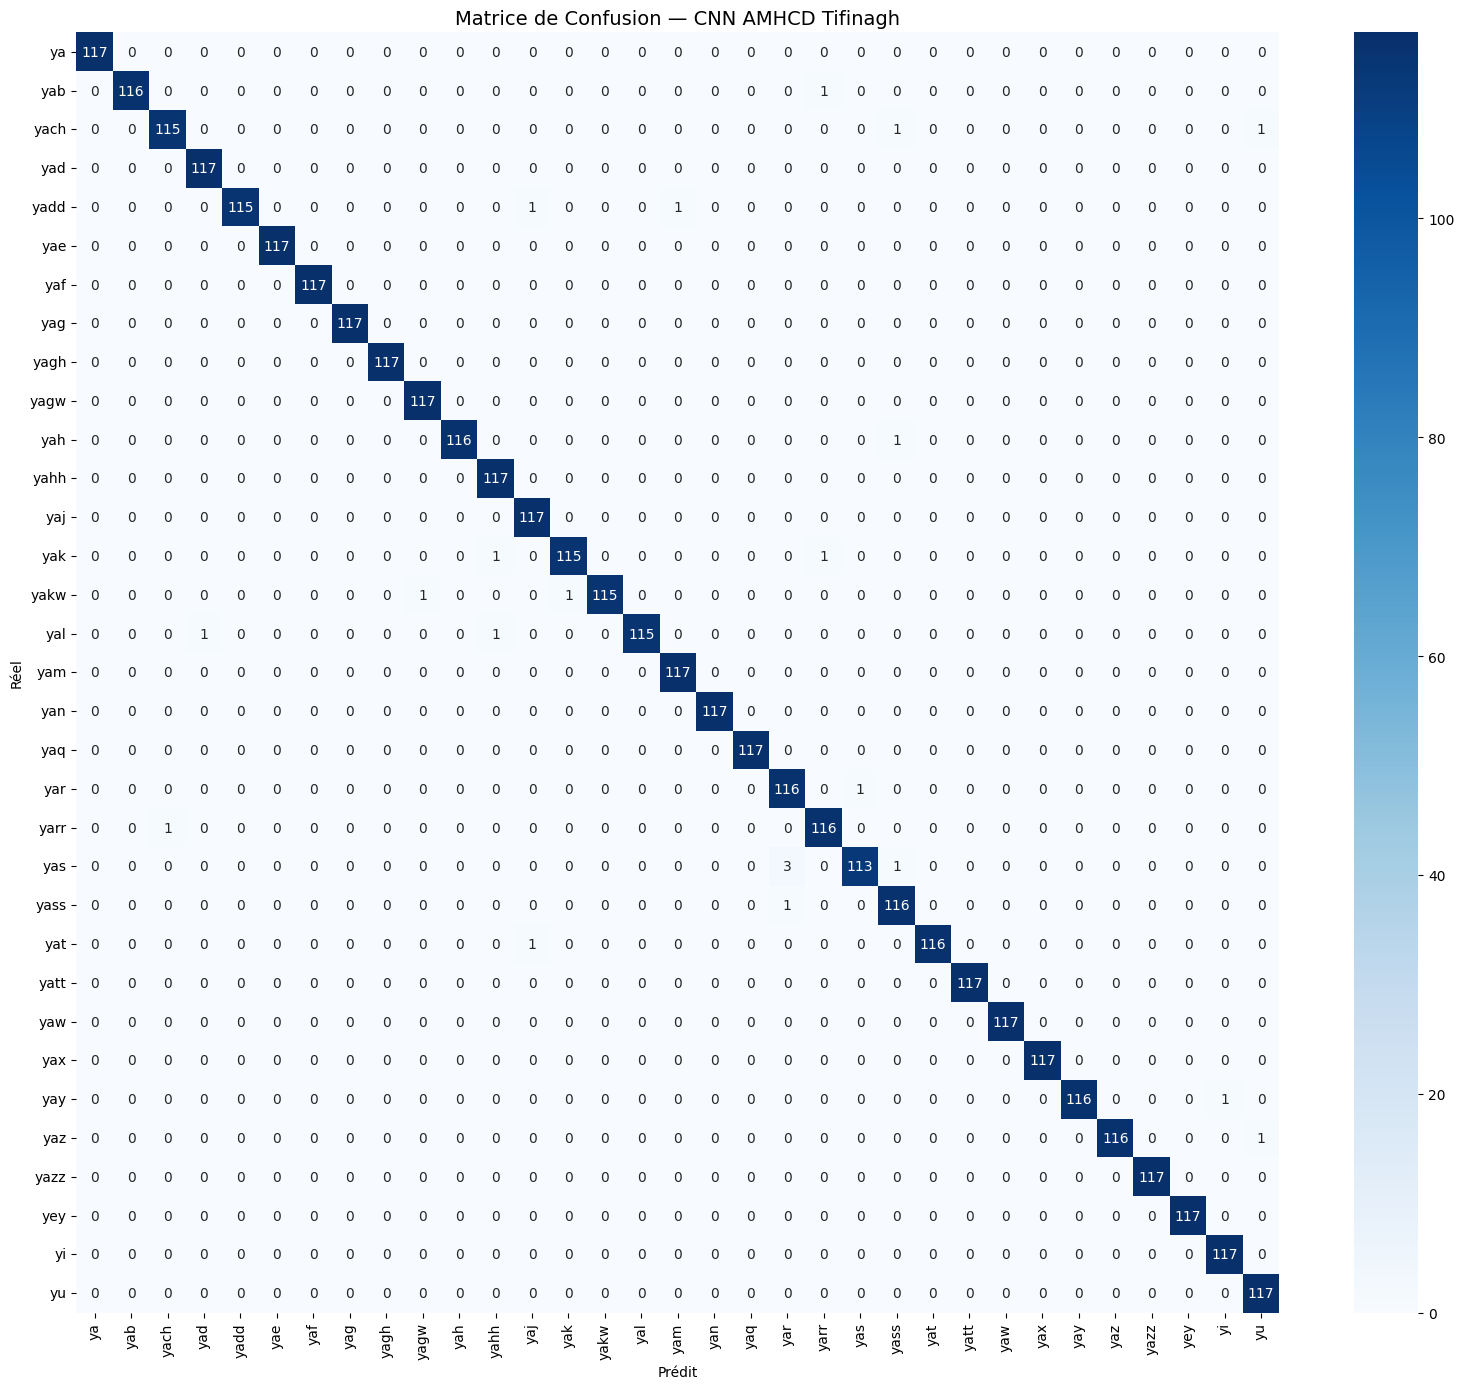

In [8]:
# ─── 7. ÉVALUATION SUR LE TEST ────────────────────────────
print("\n Évaluation sur le set de test :")
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy : {test_acc*100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")


# ─── 8. RAPPORT DE CLASSIFICATION ─────────────────────────
y_pred_classes = np.argmax(model.predict(X_test, verbose=0), axis=1)
y_true_classes = np.argmax(y_test, axis=1)

print("\n Rapport de classification :")
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))


# ─── 9. MATRICE DE CONFUSION ──────────────────────────────
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Matrice de Confusion — CNN AMHCD Tifinagh", fontsize=14)
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.tight_layout()
plt.savefig("../results/figures/matrice_confusion.png")
plt.show()


In [9]:
# ─── 10. SAUVEGARDE FINALE ────────────────────────────────
model.save("../results/models/cnn_tifinagh_final.h5")
print("\n Modèle sauvegardé dans results/models/")
print(f"\n Résultat final : {test_acc*100:.2f}%")


 Modèle sauvegardé dans results/models/

 Résultat final : 99.43%
